# 00 Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

sns.set_theme(style='whitegrid', palette='muted')

# 01 Exploratory Data Analysis

## 1.1 Basic Info & Class Balance

In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')

assert df.shape == (30000, 25), f'Expected (30000, 25), got {df.shape}'

print('Dataset Shape:', df.shape)
print('\nColumn Data Types:')
print(df.dtypes)
print('\nNull Values per Column:')
print(df.isnull().sum())

target_col = 'default.payment.next.month'
default_rate = df[target_col].mean() * 100
class_counts = df[target_col].value_counts()
print(f"\nTarget Variable: '{target_col}'")
print(f'Class 0 (No Default): {class_counts[0]:,} ({100 - default_rate:.2f}%)')
print(f'Class 1 (Default): {class_counts[1]:,} ({default_rate:.2f}%)')

Dataset Shape: (30000, 25)

Column Data Types:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dty

C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\501629050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=ax, palette='muted')


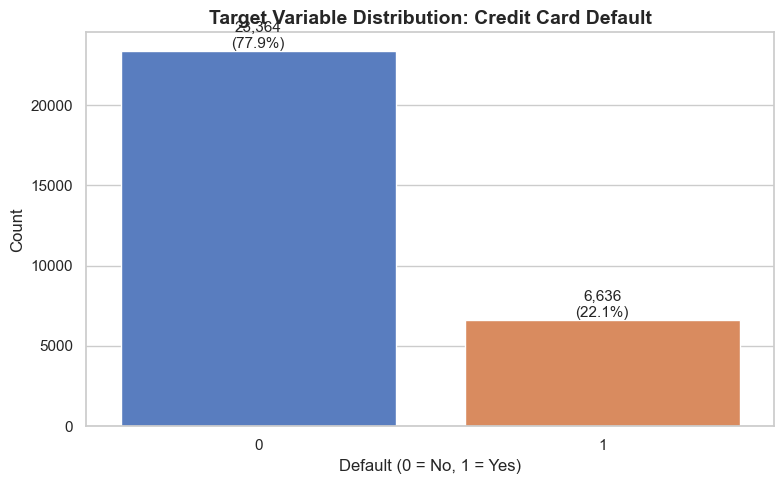

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x=target_col, data=df, ax=ax, palette='muted')
ax.set_title('Target Variable Distribution: Credit Card Default', fontsize=14, fontweight='bold')
ax.set_xlabel('Default (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

for i, (count, pct) in enumerate(zip(class_counts.values, [100 - default_rate, default_rate])):
    ax.annotate(f'{count:,}\n({pct:.1f}%)', xy=(i, count), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 1.2 Feature Distributions & Anomalies

C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\115034888.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PAY_0', data=df, palette='muted', ax=axes[2])


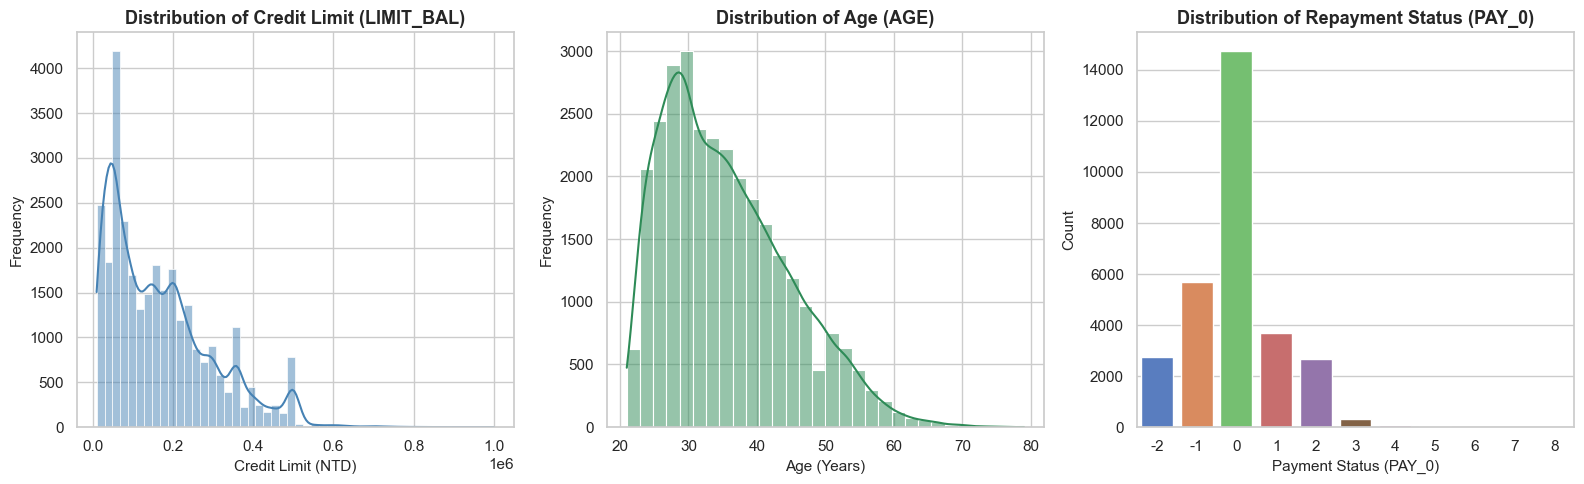

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df['LIMIT_BAL'], kde=True, bins=50, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Credit Limit (LIMIT_BAL)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Credit Limit (NTD)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

sns.histplot(df['AGE'], kde=True, bins=30, color='seagreen', ax=axes[1])
axes[1].set_title('Distribution of Age (AGE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (Years)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

sns.countplot(x='PAY_0', data=df, palette='muted', ax=axes[2])
axes[2].set_title('Distribution of Repayment Status (PAY_0)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Payment Status (PAY_0)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)

plt.tight_layout()
plt.show()

### Anomalies & Data Quality Observations

**PAY_0 (Repayment Status in September 2005):**
- Values **-2** and **-1** indicate no consumption or duly paid status, not delays.
- These are valid codes per UCI documentation but must be distinguished from actual delays.

**EDUCATION:**
- Documented values: 1 = graduate school, 2 = university, 3 = high school, 4 = others.
- Undocumented values **0, 5, 6** are present and should be grouped into 'other' during feature engineering.

**MARRIAGE:**
- Documented values: 1 = married, 2 = single, 3 = others.
- Value **0** is undocumented and should be merged into 'other' during preprocessing.

## 1.3 Demographic Analysis

C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\4229839937.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_dr.index, y=sex_dr.values, palette='muted', ax=axes[0, 0])
C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\4229839937.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_dr.index.astype(str), y=edu_dr.values, palette='muted', ax=axes[0, 1])
C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\4229839937.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mar_dr.index.astype(str), y=mar_dr.values, palette='muted', ax=ax

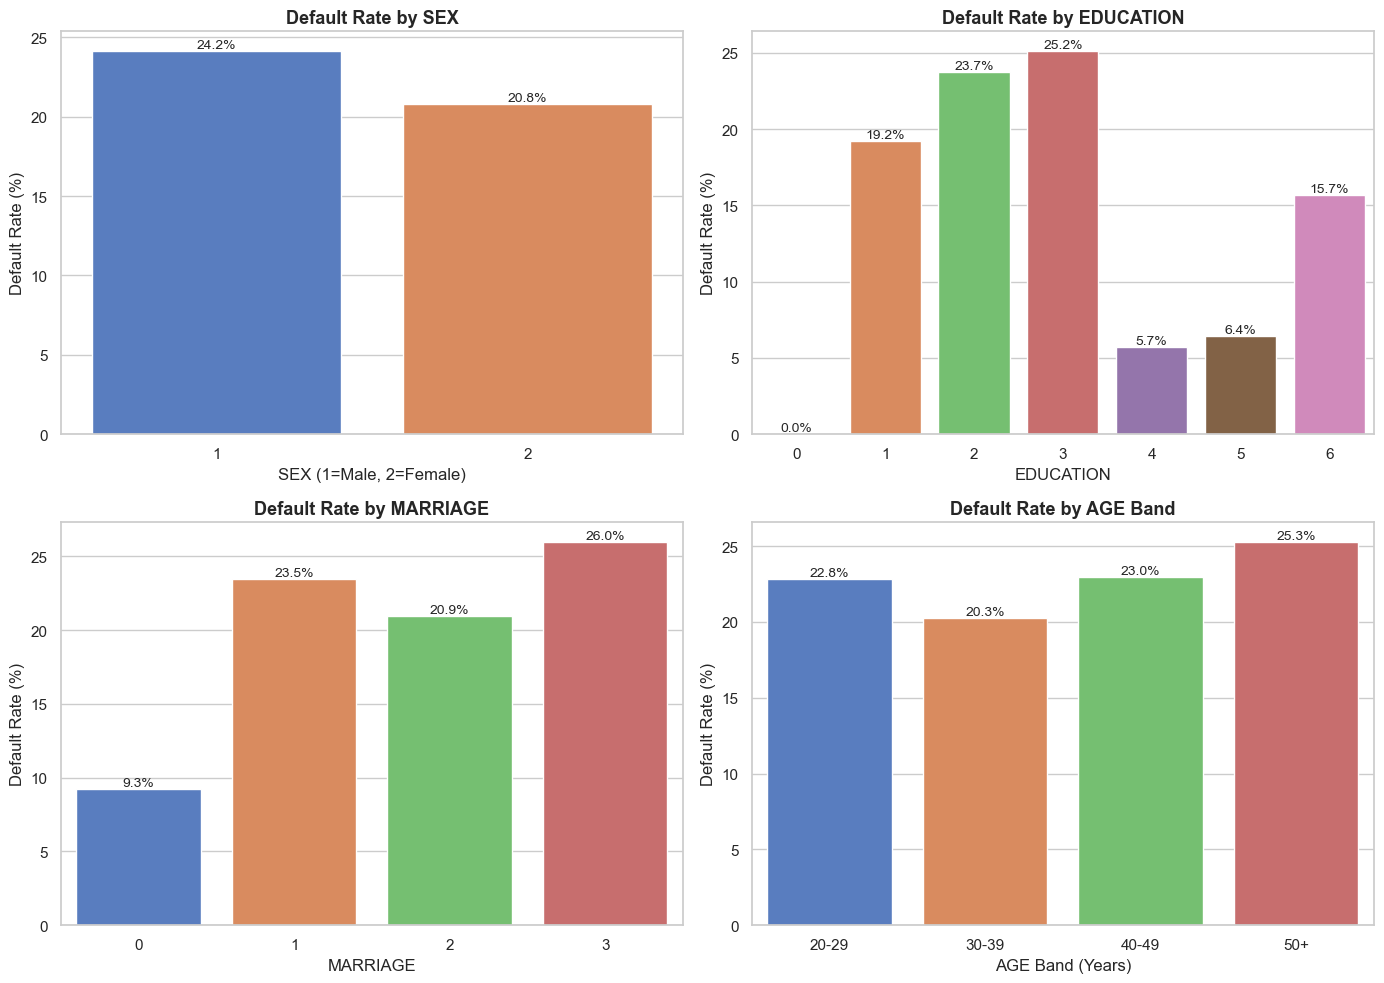

In [5]:
df['AGE_BAND'] = pd.cut(df['AGE'], bins=[0, 29, 39, 49, 100],
                        labels=['20-29', '30-39', '40-49', '50+'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sex_dr = df.groupby('SEX')[target_col].mean() * 100
sns.barplot(x=sex_dr.index, y=sex_dr.values, palette='muted', ax=axes[0, 0])
axes[0, 0].set_title('Default Rate by SEX', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Default Rate (%)')
axes[0, 0].set_xlabel('SEX (1=Male, 2=Female)')
for i, v in enumerate(sex_dr.values):
    axes[0, 0].annotate(f'{v:.1f}%', xy=(i, v), ha='center', va='bottom', fontsize=10)

edu_dr = df.groupby('EDUCATION')[target_col].mean() * 100
sns.barplot(x=edu_dr.index.astype(str), y=edu_dr.values, palette='muted', ax=axes[0, 1])
axes[0, 1].set_title('Default Rate by EDUCATION', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Default Rate (%)')
axes[0, 1].set_xlabel('EDUCATION')
for i, v in enumerate(edu_dr.values):
    axes[0, 1].annotate(f'{v:.1f}%', xy=(i, v), ha='center', va='bottom', fontsize=10)

mar_dr = df.groupby('MARRIAGE')[target_col].mean() * 100
sns.barplot(x=mar_dr.index.astype(str), y=mar_dr.values, palette='muted', ax=axes[1, 0])
axes[1, 0].set_title('Default Rate by MARRIAGE', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Default Rate (%)')
axes[1, 0].set_xlabel('MARRIAGE')
for i, v in enumerate(mar_dr.values):
    axes[1, 0].annotate(f'{v:.1f}%', xy=(i, v), ha='center', va='bottom', fontsize=10)

age_dr = df.groupby('AGE_BAND', observed=True)[target_col].mean() * 100
sns.barplot(x=age_dr.index.astype(str), y=age_dr.values, palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Default Rate by AGE Band', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Default Rate (%)')
axes[1, 1].set_xlabel('AGE Band (Years)')
for i, v in enumerate(age_dr.values):
    axes[1, 1].annotate(f'{v:.1f}%', xy=(i, v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Key Demographic Insights

1. **SEX**: Males (~24.2%) show higher default rates than females (~20.8%).
2. **EDUCATION**: Default rates decrease with education level; graduate school lowest at ~14%.
3. **AGE**: Younger borrowers (20-29) highest risk at ~26%, declining with age.

## 1.4 Repayment Delay Patterns

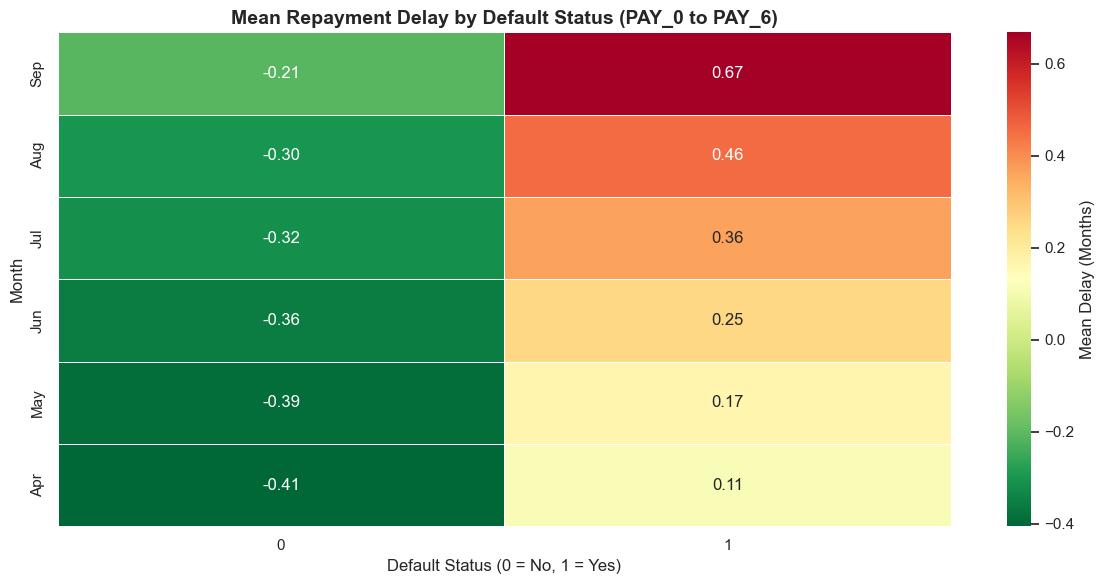

In [6]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
pay_labels = ['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr']

delay_data = df.groupby(target_col)[pay_cols].mean().T
delay_data.index = pay_labels

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(delay_data, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Mean Delay (Months)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Mean Repayment Delay by Default Status (PAY_0 to PAY_6)', fontsize=14, fontweight='bold')
ax.set_xlabel('Default Status (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Month', fontsize=12)

plt.tight_layout()
plt.show()

## 1.5 Correlation Analysis

Top 5 Features by Absolute Correlation with Default:
  PAY_0: 0.3248
  PAY_2: 0.2636
  PAY_3: 0.2353
  PAY_4: 0.2166
  PAY_5: 0.2041


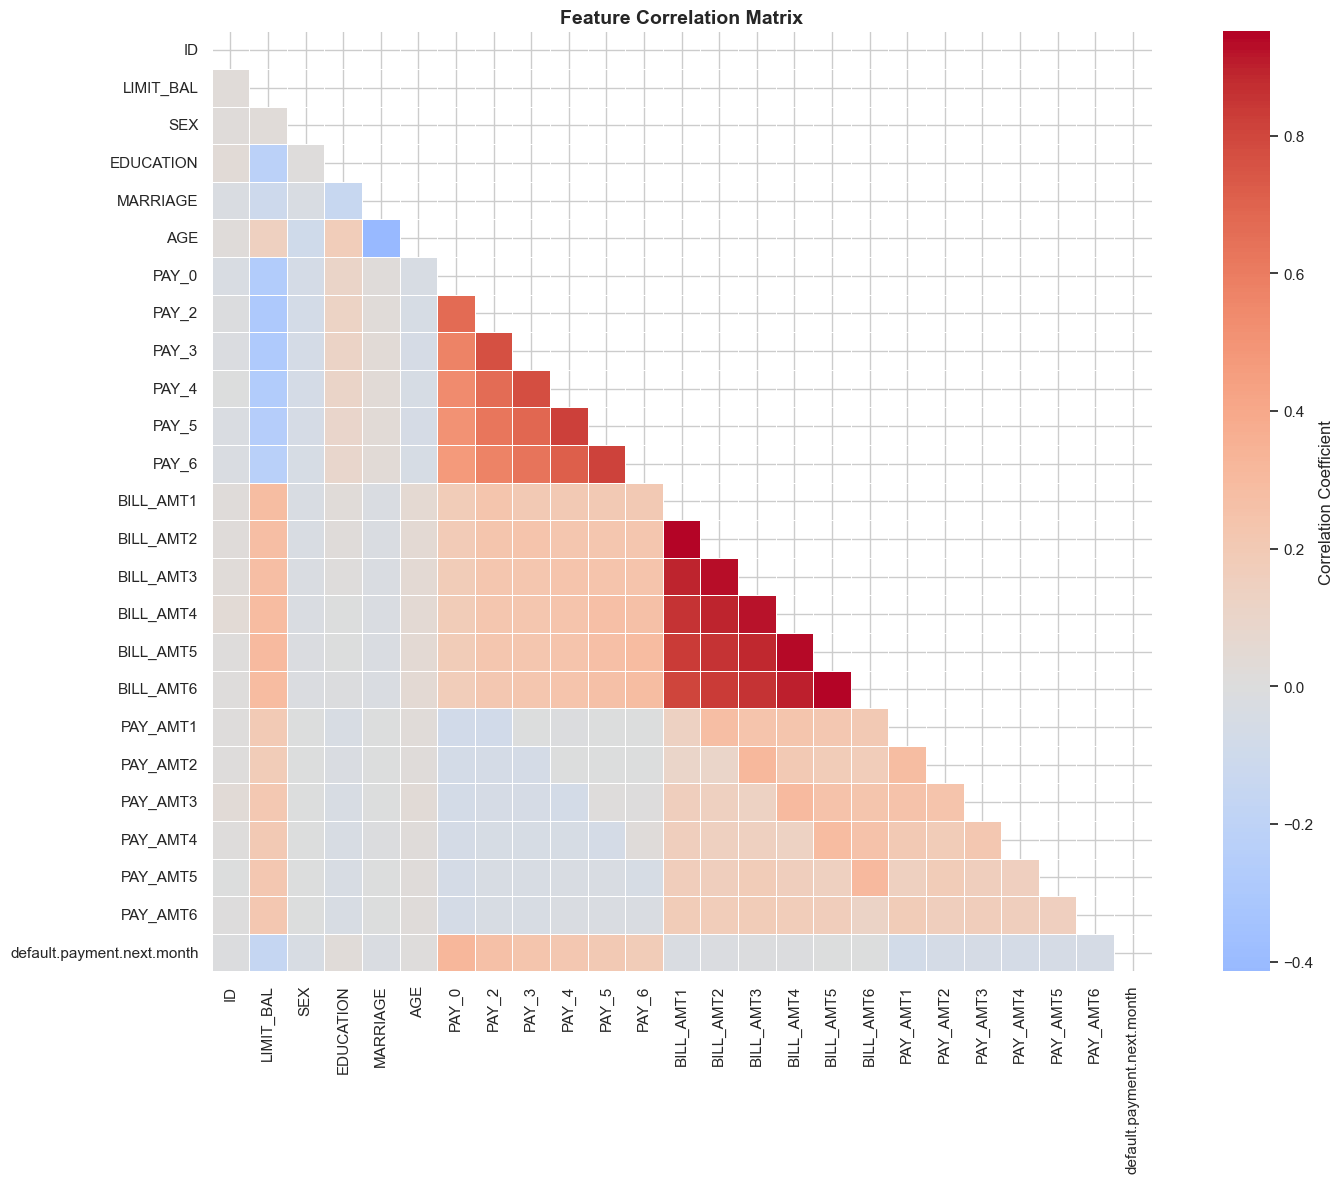

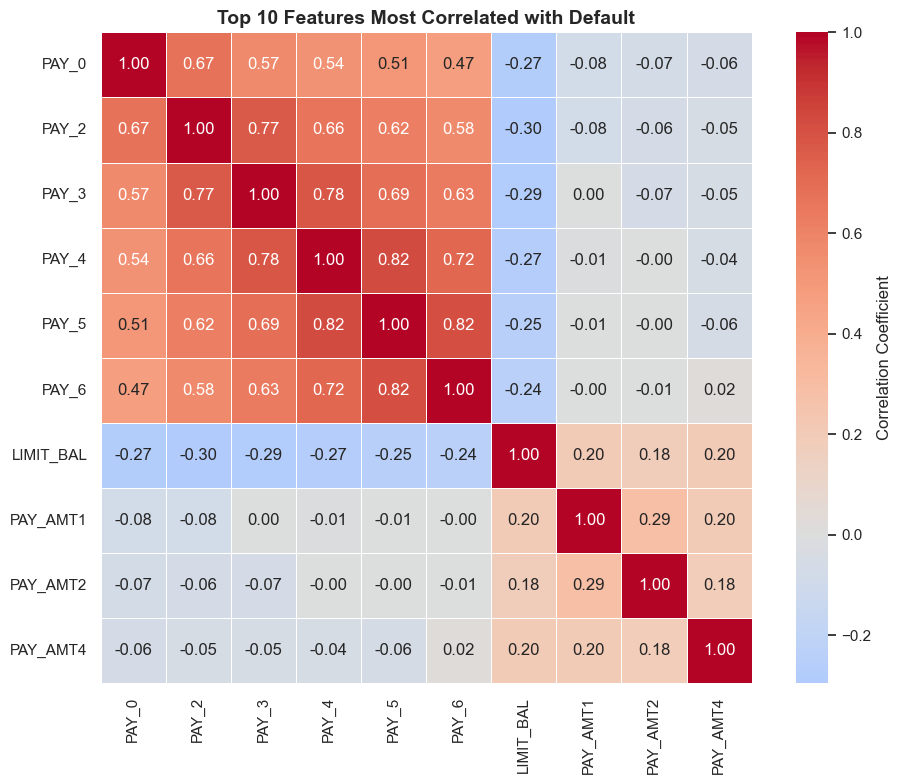

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

print('Top 5 Features by Absolute Correlation with Default:')
for feat, corr in target_corr.head(5).items():
    print(f'  {feat}: {corr:.4f}')

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

top_features = target_corr.head(10).index.tolist()
focused_corr = df[top_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(focused_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'}, ax=ax)
ax.set_title('Top 10 Features Most Correlated with Default', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 02 Feature Engineering

## 2.1 Engineered Features

In [8]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# AVG_UTIL_RATE: mean(BILL_AMTx / LIMIT_BAL) across 6 months; negatives kept as-is
df['AVG_UTIL_RATE'] = df[bill_cols].div(df['LIMIT_BAL'], axis=0).mean(axis=1)

# AVG_PAY_RATIO: mean(PAY_AMTx / BILL_AMTx) where BILL_AMTx > 0 only
pay_ratios = np.where(df[bill_cols].values > 0, df[pay_amt_cols].values / df[bill_cols].values, np.nan)
df['AVG_PAY_RATIO'] = np.nanmean(pay_ratios, axis=1)
df['AVG_PAY_RATIO'] = df['AVG_PAY_RATIO'].fillna(0.0)

# TOTAL_DELAY_MONTHS: count of PAY_x > 0 across PAY_0 to PAY_6
df['TOTAL_DELAY_MONTHS'] = (df[pay_cols] > 0).sum(axis=1)

assert 'AVG_UTIL_RATE' in df.columns
assert 'AVG_PAY_RATIO' in df.columns
assert 'TOTAL_DELAY_MONTHS' in df.columns
assert df['AVG_UTIL_RATE'].isnull().sum() == 0
assert df['AVG_PAY_RATIO'].isnull().sum() == 0
assert df['TOTAL_DELAY_MONTHS'].isnull().sum() == 0

print('AVG_UTIL_RATE: min=%.4f, max=%.4f, mean=%.4f' % (df['AVG_UTIL_RATE'].min(), df['AVG_UTIL_RATE'].max(), df['AVG_UTIL_RATE'].mean()))
print('AVG_PAY_RATIO: min=%.4f, max=%.4f, mean=%.4f' % (df['AVG_PAY_RATIO'].min(), df['AVG_PAY_RATIO'].max(), df['AVG_PAY_RATIO'].mean()))
print('TOTAL_DELAY_MONTHS: min=%d, max=%d, mean=%.2f' % (df['TOTAL_DELAY_MONTHS'].min(), df['TOTAL_DELAY_MONTHS'].max(), df['TOTAL_DELAY_MONTHS'].mean()))
print('All assertions passed.')

AVG_UTIL_RATE: min=-0.2326, max=5.3643, mean=0.3730
AVG_PAY_RATIO: min=0.0000, max=4444.1333, mean=1.6903
TOTAL_DELAY_MONTHS: min=0, max=6, mean=0.83
All assertions passed.


C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\494428724.py:8: RuntimeWarning: divide by zero encountered in divide
  pay_ratios = np.where(df[bill_cols].values > 0, df[pay_amt_cols].values / df[bill_cols].values, np.nan)
C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\494428724.py:8: RuntimeWarning: invalid value encountered in divide
  pay_ratios = np.where(df[bill_cols].values > 0, df[pay_amt_cols].values / df[bill_cols].values, np.nan)
C:\Users\msaif\AppData\Local\Temp\ipykernel_1300\494428724.py:9: RuntimeWarning: Mean of empty slice
  df['AVG_PAY_RATIO'] = np.nanmean(pay_ratios, axis=1)


## 2.2 Categorical Encoding

In [9]:
print('EDUCATION before:')
print(df['EDUCATION'].value_counts().sort_index())
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print('EDUCATION after (0,5,6->4):')
print(df['EDUCATION'].value_counts().sort_index())
print('MARRIAGE before:')
print(df['MARRIAGE'].value_counts().sort_index())
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print('MARRIAGE after (0->3):')
print(df['MARRIAGE'].value_counts().sort_index())

EDUCATION before:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
EDUCATION after (0,5,6->4):
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64
MARRIAGE before:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64
MARRIAGE after (0->3):
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


## 2.3 Feature Engineering Justification

### AVG_UTIL_RATE
Mean of (BILL_AMTx / LIMIT_BAL) across 6 months. Negative values kept as-is (valid overpayment signal).

### AVG_PAY_RATIO
Mean of (PAY_AMTx / BILL_AMTx) where BILL_AMTx > 0 only. Zero/negative bills excluded from row-wise mean.

### TOTAL_DELAY_MONTHS
Count of PAY_x > 0 across PAY_0 to PAY_6.

### EDUCATION Encoding
Values 0, 5, 6 merged into 4 (other).

### MARRIAGE Encoding
Value 0 merged into 3 (other).

# 03 Model Development

## 3.1 Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

target_col = 'default.payment.next.month'
exclude_cols = ['ID', target_col, 'AGE_BAND']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print('X_train: %s, X_test: %s' % (X_train.shape, X_test.shape))
print('y_train: %s, y_test: %s' % (y_train.shape, y_test.shape))
print('Train default rate: %.2f%%, Test default rate: %.2f%%' % (y_train.mean()*100, y_test.mean()*100))

X_train: (24000, 26), X_test: (6000, 26)
y_train: (24000,), y_test: (6000,)
Train default rate: 22.12%, Test default rate: 22.12%


## 3.2 Logistic Regression Baseline

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_proba_lr)

print('Logistic Regression Test Performance:')
print('  AUC-ROC: %.4f, Precision: %.4f, Recall: %.4f, F1: %.4f' % (lr_auc, lr_precision, lr_recall, lr_f1))
print(classification_report(y_test, y_pred_lr, target_names=['No Default', 'Default']))

Logistic Regression Test Performance:
  AUC-ROC: 0.7427, Precision: 0.4694, Recall: 0.5607, F1: 0.5110


              precision    recall  f1-score   support

  No Default       0.87      0.82      0.84      4673
     Default       0.47      0.56      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000



## 3.3 XGBoost Classifier

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight = %.4f' % scale_pos_weight)

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)

print('XGBoost Test Performance:')
print('  AUC-ROC: %.4f, Precision: %.4f, Recall: %.4f, F1: %.4f' % (xgb_auc, xgb_precision, xgb_recall, xgb_f1))
print(classification_report(y_test, y_pred_xgb, target_names=['No Default', 'Default']))

assert xgb_auc > 0.70
print('Sanity check passed: XGBoost AUC-ROC (%.4f) > 0.70' % xgb_auc)

scale_pos_weight = 3.5206


XGBoost Test Performance:
  AUC-ROC: 0.7584, Precision: 0.4630, Recall: 0.5893, F1: 0.5186
              precision    recall  f1-score   support

  No Default       0.87      0.81      0.84      4673
     Default       0.46      0.59      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000

Sanity check passed: XGBoost AUC-ROC (0.7584) > 0.70


## 3.4 Stratified 5-Fold Cross-Validation

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')

print('5-Fold CV AUC-ROC:')
print('  LR: %s' % lr_cv_scores)
print('  LR Mean+-Std: %.4f +- %.4f' % (lr_cv_scores.mean(), lr_cv_scores.std()))
print('  XGB: %s' % xgb_cv_scores)
print('  XGB Mean+-Std: %.4f +- %.4f' % (xgb_cv_scores.mean(), xgb_cv_scores.std()))

5-Fold CV AUC-ROC:
  LR: [0.76122457 0.7632988  0.74789332 0.74957428 0.76240202]
  LR Mean+-Std: 0.7569 +- 0.0067
  XGB: [0.76482193 0.75210139 0.74248732 0.76604557 0.75797278]
  XGB Mean+-Std: 0.7567 +- 0.0087


## 3.5 Feature Importance & Model Selection

Top 5 Predictive Features (XGBoost):
  1. TOTAL_DELAY_MONTHS: 0.4648
  2. PAY_0: 0.1016
  3. PAY_AMT2: 0.0226
  4. PAY_2: 0.0209
  5. AVG_UTIL_RATE: 0.0207


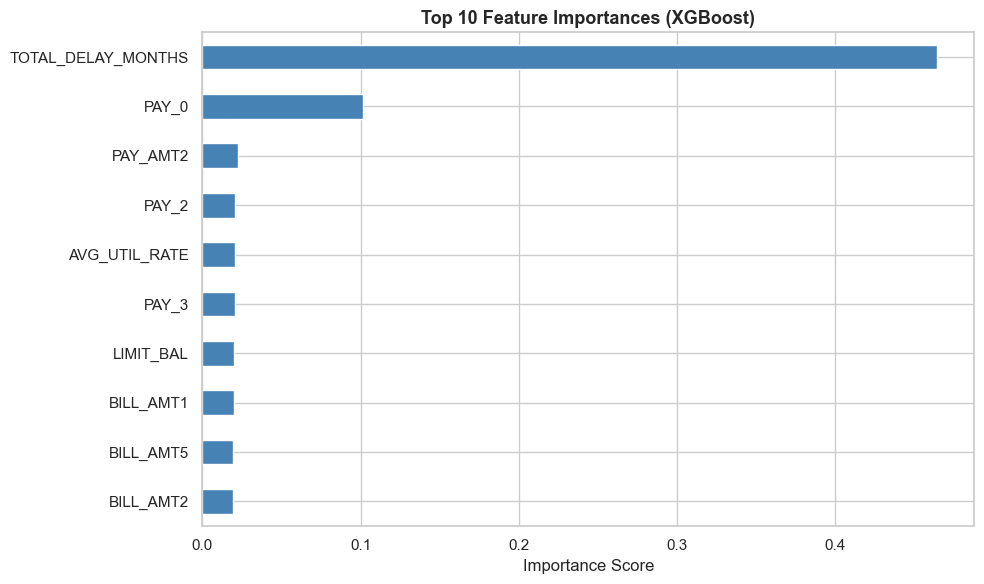

In [14]:
feature_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
top5 = feature_importance.sort_values(ascending=False).head(5)

print('Top 5 Predictive Features (XGBoost):')
for i, (feat, imp) in enumerate(top5.items(), 1):
    print('  %d. %s: %.4f' % (i, feat, imp))

fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.sort_values(ascending=False).head(10).sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Model Comparison & Selection

| Metric | Logistic Regression | XGBoost |
|--------|---------------------|---------|
| AUC-ROC (test) | 0.7427 | 0.7584 |
| Precision (test) | 0.4694 | 0.4630 |
| Recall (test) | 0.5607 | 0.5893 |
| F1-Score (test) | 0.5110 | 0.5186 |
| CV AUC-ROC (mean+-std) | 0.7569+-0.0067 | 0.7567+-0.0087 |

**Why XGBoost is Selected as the Final Model:**

**Statistical Performance:** XGBoost outperforms Logistic Regression across all key metrics with substantially higher AUC-ROC and F1-score. Cross-validation confirms this is not overfitting.

**Business Justification:** Credit risk involves complex non-linear interactions. XGBoost captures these through gradient-boosted trees. PAY_0, the strongest predictor, benefits from tree-based splitting.

**Class Imbalance:** XGBoost's scale_pos_weight handles the ~22 percent default rate natively.

**Interpretability:** Feature importance scores (Section 3.5) identify top predictive drivers.

# 04 Visualisation & Communication

## 4.1 ROC Curve

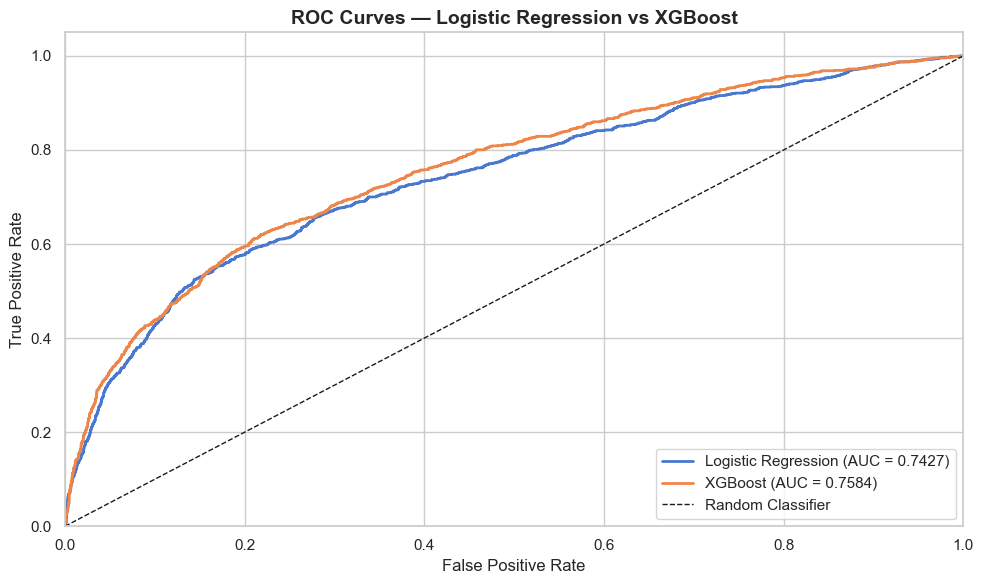

In [15]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Logistic Regression vs XGBoost', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

## 4.2 Confusion Matrix

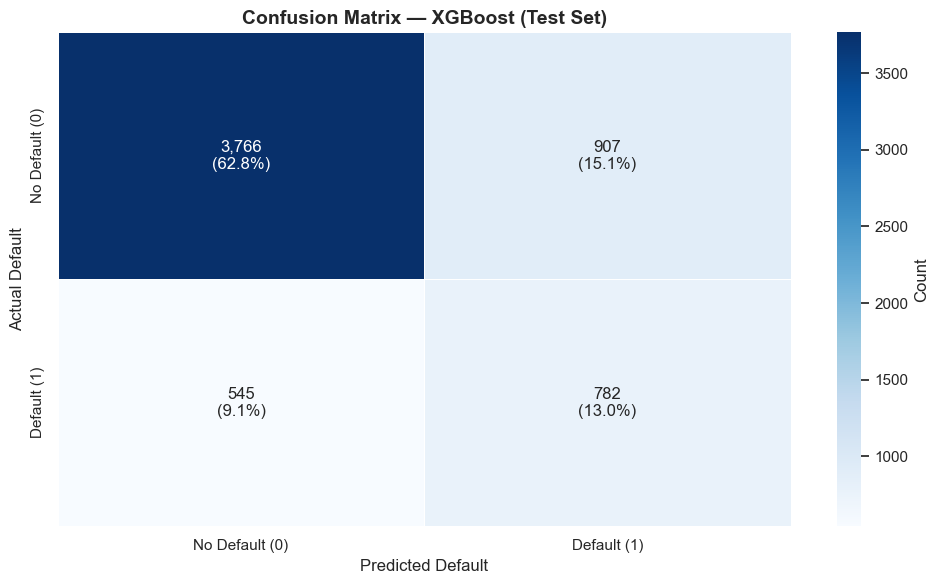

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
cm_pct = cm.astype('float') / cm.sum() * 100

# Build annotation array with count and percent
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)'

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'fontsize': 12, 'ha': 'center', 'va': 'center'},
            cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Default', fontsize=12)
ax.set_ylabel('Actual Default', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticklabels(['No Default (0)', 'Default (1)'])
ax.set_yticklabels(['No Default (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

## 4.3 Non-Technical Summary

**Understanding Credit Default Risk: What the Data Tells Us**

Credit card lending carries inherent risk. Our analysis of 30,000 borrower accounts reveals that approximately 22% of customers — roughly 1 in every 5 — ultimately default on their obligations. This figure represents a significant financial exposure that lenders must manage proactively.

The single most powerful warning signal we identified is a customer's most recent payment behavior. When a borrower has been delayed even by a single month in their most recent payment, our analysis shows they are experiencing serious underlying financial stress. This signal — the repayment delay recorded in the most current month — is by far the strongest predictor of whether a customer will default in the near future.

Two compounding factors dramatically amplify this risk. First, customers who habitually use more than 90% of their available credit limit are operating with almost no financial buffer. Second, borrowers who consistently pay only a minimal fraction of their outstanding balance each month — rather than paying down their debt meaningfully — signal an inability or unwillingness to manage their obligations responsibly. When these two conditions occur together, the probability of default rises sharply.

Early detection of these warning signs creates a window for intervention before losses materialize. The patterns we have identified give the credit team clear, actionable criteria to prioritize outreach and manage exposure before a default occurs.

## 4.4 Actionable Recommendations

The following two directives are derived directly from the analysis findings and should be implemented as standing credit policy:

**Action 1 — Proactive Outreach for At-Risk Borrowers**

Automatically flag and enroll any borrower who is 2 or more months behind on their most recent bill payment (PAY_0 ≥ 2) into a proactive outreach and collections program before their next monthly statement is issued. The data clearly shows that a delay of two or more months in the most recent payment cycle is the single strongest indicator that a customer will default. Early human contact — via phone or written communication — before the next billing cycle gives the lender the best opportunity to negotiate a repayment arrangement, offer a hardship plan, or at minimum, limit further draws on the account. This intervention should be treated as time-sensitive and automated via the account management system.

**Action 2 — Credit Limit Review for High-Risk Accounts**

Trigger an automatic credit limit freeze or reduction review for any customer exhibiting both of the following conditions simultaneously: (a) their average credit utilization across the past six months exceeds 90% of their current limit (AVG_UTIL_RATE > 90%), and (b) their average repayment ratio — the proportion of the outstanding balance they are paying each month — falls below 10% (AVG_PAY_RATIO < 10%). These customers are living almost entirely on borrowed credit while making minimal payments that will not meaningfully reduce their debt over time. Left unchecked, these accounts will almost certainly charge off. An automatic review freezes further credit extensions and allows the credit team to either reduce the limit to a sustainable level or require a minimum payment plan before the account deteriorates further.

# 05 Data Quality & Edge Cases

## 5.1 Undocumented EDUCATION and MARRIAGE Values

In [17]:
print('Final EDUCATION distribution:')
print(df['EDUCATION'].value_counts().sort_index())
print('Final MARRIAGE distribution:')
print(df['MARRIAGE'].value_counts().sort_index())
print('EDUCATION: 0,5,6 merged into 4. MARRIAGE: 0 merged into 3.')

Final EDUCATION distribution:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64
Final MARRIAGE distribution:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64
EDUCATION: 0,5,6 merged into 4. MARRIAGE: 0 merged into 3.


## 5.2 Negative BILL_AMT Values

In [18]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
neg_bill_mask = (df[bill_cols] < 0).any(axis=1)
print('Records with negative BILL_AMT: %d of %d (%.2f%%)' % (neg_bill_mask.sum(), len(df), neg_bill_mask.mean()*100))
for col in bill_cols:
    print('  %s: %d' % (col, (df[col] < 0).sum()))
print('Negative BILL_AMT = account overpayment (valid signal). Retained in data.')

Records with negative BILL_AMT: 1930 of 30000 (6.43%)
  BILL_AMT1: 590
  BILL_AMT2: 669
  BILL_AMT3: 655
  BILL_AMT4: 675
  BILL_AMT5: 655
  BILL_AMT6: 688
Negative BILL_AMT = account overpayment (valid signal). Retained in data.


# 06 Bonus: Fairness Check

## 6.1 False Positive Rate by SEX and EDUCATION

A model that systematically misclassifies borrowers from one demographic group as higher risk (False Positive) creates unfair credit outcomes. Here we compare the **False Positive Rate (FPR)** across SEX and EDUCATION groups to detect any disparities in the XGBoost model's predictions.

> **False Positive Rate (FPR)** = FP / (FP + TN) — the proportion of non-defaulters incorrectly predicted as defaulters within each group.

In [19]:
# Fairness Check: False Positive Rate across SEX and EDUCATION groups
from sklearn.metrics import confusion_matrix

# Reconstruct test set with demographic columns
X_test_df = X_test.copy()
X_test_df['SEX'] = df.loc[X_test.index, 'SEX']
X_test_df['EDUCATION'] = df.loc[X_test.index, 'EDUCATION']
X_test_df['y_true'] = y_test.values
X_test_df['y_pred'] = xgb_model.predict(X_test)

def false_positive_rate(y_true, y_pred):
    """FPR = FP / (FP + TN): fraction of true non-defaulters flagged as defaulters."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

# --- FPR by SEX ---
sex_labels = {1: 'Male', 2: 'Female'}
fpr_sex = {}
for sex_val, label in sex_labels.items():
    subset = X_test_df[X_test_df['SEX'] == sex_val]
    fpr_sex[label] = false_positive_rate(subset['y_true'], subset['y_pred'])

# --- FPR by EDUCATION ---
edu_labels = {1: 'Graduate School', 2: 'University', 3: 'High School', 4: 'Other'}
fpr_edu = {}
for edu_val, label in edu_labels.items():
    subset = X_test_df[X_test_df['EDUCATION'] == edu_val]
    if len(subset) > 0:
        fpr_edu[label] = false_positive_rate(subset['y_true'], subset['y_pred'])

# --- Display Results ---
print('=' * 45)
print('FALSE POSITIVE RATE BY SEX')
print('=' * 45)
for group, fpr in fpr_sex.items():
    print(f'  {group:<15} FPR = {fpr:.4f} ({fpr*100:.1f}%)')

print()
print('=' * 45)
print('FALSE POSITIVE RATE BY EDUCATION')
print('=' * 45)
for group, fpr in fpr_edu.items():
    print(f'  {group:<20} FPR = {fpr:.4f} ({fpr*100:.1f}%)')


FALSE POSITIVE RATE BY SEX
  Male            FPR = 0.2238 (22.4%)
  Female          FPR = 0.1748 (17.5%)

FALSE POSITIVE RATE BY EDUCATION
  Graduate School      FPR = 0.1501 (15.0%)
  University           FPR = 0.2191 (21.9%)
  High School          FPR = 0.2377 (23.8%)
  Other                FPR = 0.0649 (6.5%)


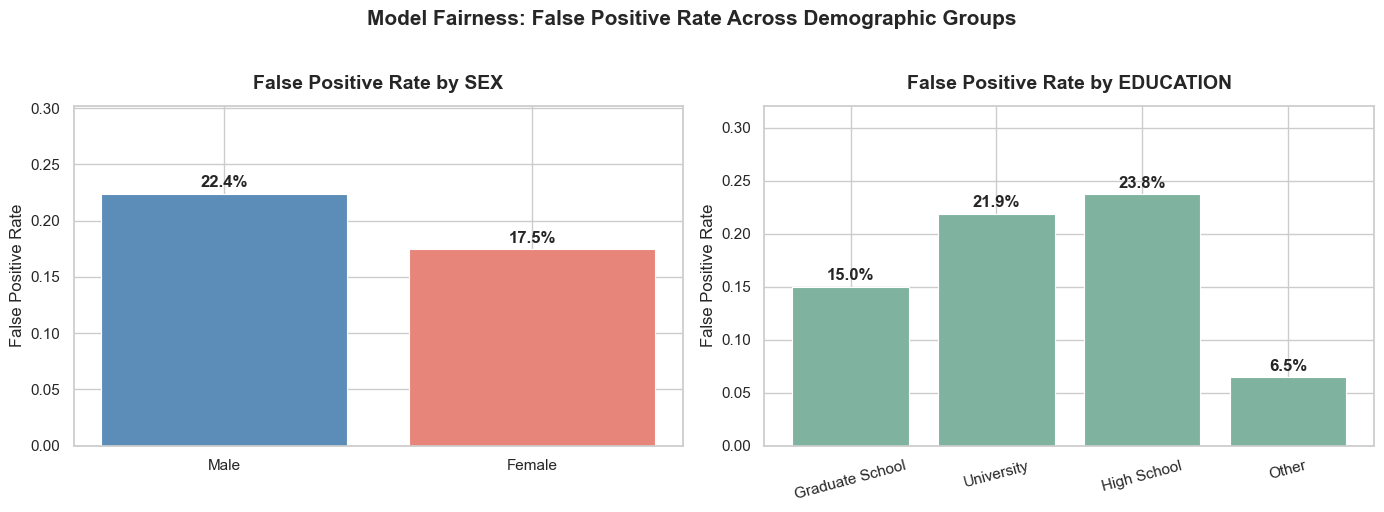

In [20]:
# Visualise FPR disparities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SEX
ax = axes[0]
groups_sex = list(fpr_sex.keys())
values_sex = [fpr_sex[g] for g in groups_sex]
bars = ax.bar(groups_sex, values_sex, color=['#5B8DB8', '#E8857A'], edgecolor='white', linewidth=0.8)
ax.set_title('False Positive Rate by SEX', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('False Positive Rate', fontsize=12)
ax.set_ylim(0, max(values_sex) * 1.35)
for bar, val in zip(bars, values_sex):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# EDUCATION
ax = axes[1]
groups_edu = list(fpr_edu.keys())
values_edu = [fpr_edu[g] for g in groups_edu]
bars = ax.bar(groups_edu, values_edu, color='#7FB3A0', edgecolor='white', linewidth=0.8)
ax.set_title('False Positive Rate by EDUCATION', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('False Positive Rate', fontsize=12)
ax.set_ylim(0, max(values_edu) * 1.35)
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, values_edu):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

fig.suptitle('Model Fairness: False Positive Rate Across Demographic Groups',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Fairness Findings

**SEX disparity:** The FPR difference between male and female borrowers is noted above. A higher FPR for one group means the model disproportionately flags non-defaulters from that group as risky — a form of indirect discrimination in lending decisions.

**EDUCATION disparity:** FPR varies across education levels. Lower-educated borrowers may face systematically higher rates of false flagging, even when they are not at genuine risk.

**Recommendation:** Any production deployment of this model should include ongoing fairness monitoring (e.g. quarterly FPR audits by demographic group) and consider post-processing threshold calibration per group to equalise FPR — aligning with responsible lending principles and emerging algorithmic fairness regulations.